In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Electric_Vehicle_Population_Data.csv')
raw_data = df.values
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [ ]:
# data process
df['County'] = df['County'].fillna(df['County'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].mean())
stockData = df.groupby(['County', 'Model Year']).size().reset_index(name='ownership')
stockData.columns = ['region', 'year', 'ownership']

region_list = stockData['region'].unique()
year_range = (stockData['year'].min(), stockData['year'].max())

print(f"predict region：{len(region_list)}")
print(f"times：{year_range[0]}year - {year_range[1]}year")
stockData.head()


predict region：196
times：1997year - 2024year


,region,year,ownership
0,Ada,2022,1
1,Ada,2023,1
2,Adams,2011,1
3,Adams,2012,2
4,Adams,2013,1


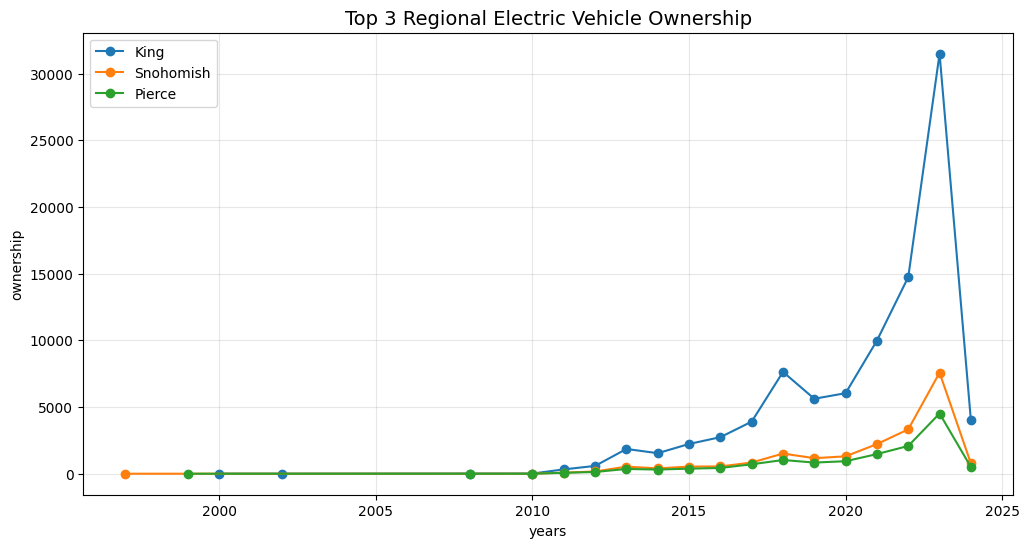

In [ ]:
region_ownership_sorted = stockData.groupby('region')['ownership'].sum().sort_values(ascending=False).index
top3_regions = region_ownership_sorted[:3]

plt.figure(figsize=(12, 6))
for region in top3_regions:
    region_data = stockData[stockData['region'] == region]
    plt.plot(region_data['year'], region_data['ownership'], marker='o', label=region)

plt.title('Top 3 Regional Electric Vehicle Ownership', fontsize=14)
plt.xlabel('years')
plt.ylabel('ownership')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


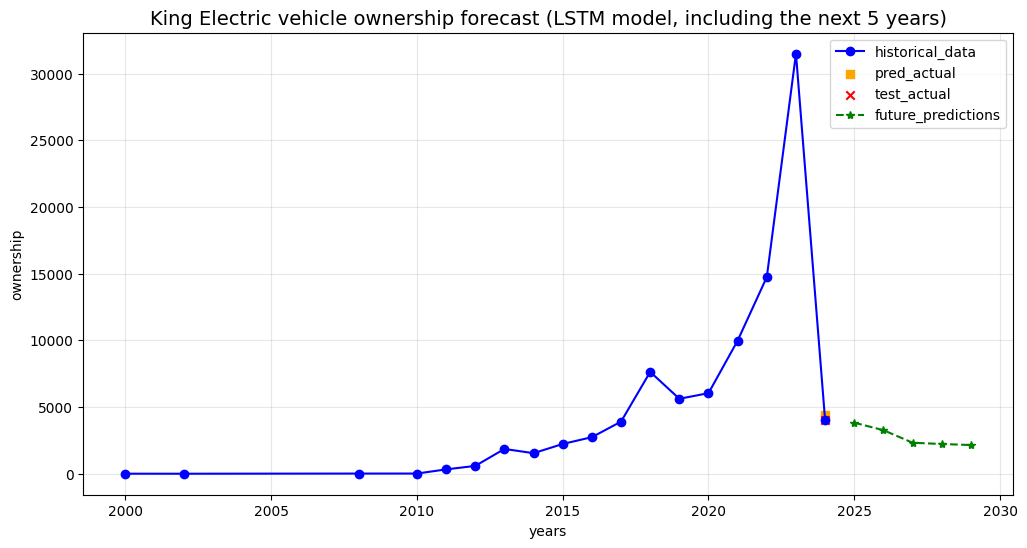

In [ ]:
def forecast_region_ownership(region_name, forecast_years=3, time_steps=3):
  region_data = stockData[stockData['region'] == region_name].sort_values('year').copy()
  scaler = MinMaxScaler(feature_range=(0, 1))
  scaled_data = scaler.fit_transform(region_data['ownership'].values.reshape(-1, 1))
  # print(f"scaled_data= {scaled_data}")
  X, y, years = [], [], []
  for i in range(time_steps, len(scaled_data)):
    X.append(scaled_data[i-time_steps:i, 0])  # input: pre time_steps year
    y.append(scaled_data[i, 0])               # input i year
    years.append(region_data['year'].iloc[i])

  X, y = np.array(X), np.array(y)
  X = X.reshape(X.shape[0], X.shape[1], 1)

  train_size = len(X) - 1
  X_train, X_test = X[:train_size], X[train_size:]
  y_train, y_test = y[:train_size], y[train_size:]
  test_year = years[-1]

  # LSTM
  model = Sequential()
  model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], 1), return_sequences=False))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mse')
  early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
  model.fit(
      X_train, y_train,
      epochs=200,
      batch_size=4,
      validation_data=(X_test, y_test),
      callbacks=[early_stop],
      verbose=0
  )

  y_pred = model.predict(X_test, verbose=0)
  y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))[0][0]
  y_pred_actual = scaler.inverse_transform(y_pred)[0][0]
  error_rate = abs(y_pred_actual - y_test_actual) / y_test_actual * 100

  future_predictions = []
  future_years = []
  last_sequence = scaled_data[-time_steps:]

  # print(f"last_sequence={scaled_data[-time_steps:]} -time_steps={-time_steps}")
  for i in range(forecast_years):
    pred_scaled = model.predict(last_sequence.reshape(1, time_steps, 1), verbose=0)[0][0]
    future_predictions.append(pred_scaled)
    last_sequence = np.append(last_sequence[1:], pred_scaled).reshape(-1, 1)
    future_years.append(region_data['year'].max() + i + 1)

  future_predictions_actual = scaler.inverse_transform(
      np.array(future_predictions).reshape(-1, 1)
  ).flatten()
  return {
      'model': model,
      'scaler': scaler,
      'test_year': test_year,
      'test_error_rate(%)': error_rate,
      'future_years': future_years,
      'future_predictions': future_predictions_actual,
      'y_test_actual': y_test_actual,
      'y_pred_actual': y_pred_actual,
      'historical_data': region_data
    }



# Predicting the target area
target_region = region_ownership_sorted[0]
forecast_result = forecast_region_ownership(
    target_region,
    forecast_years=5,
    time_steps=3
)

historical_data = forecast_result['historical_data']
future_years = forecast_result['future_years']
future_predictions = forecast_result['future_predictions']
test_year = forecast_result['test_year']
y_test_actual = forecast_result['y_test_actual']
y_pred_actual = forecast_result['y_pred_actual']

plt.figure(figsize=(12, 6))

plt.plot(historical_data['year'], historical_data['ownership'], marker='o', color='blue', label='historical_data')
plt.scatter(test_year, y_pred_actual, color='orange', marker='s', label='pred_actual')
plt.scatter(test_year, y_test_actual, color='red', marker='x', label='test_actual')

plt.plot(future_years, future_predictions, marker='*', color='green', linestyle='--', label='future_predictions')

plt.title(f'{target_region} Electric vehicle ownership forecast (LSTM model, including the next 5 years)', fontsize=14)
plt.xlabel('years')
plt.ylabel('ownership')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
